In [1]:
# import the libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt

## Initial setup

In [2]:
infile = 'video_sea.mp4'
output_folder = 'outputs/'

In [3]:
# read the video and extract the information
video = cv2.VideoCapture(infile)
frame_width = int(video.get(3))
frame_height = int(video.get(4))
print('with:',frame_width)
print('height:',frame_height)

with: 1080
height: 1920


Image size (H, W, C) is: (1920, 1080, 3)


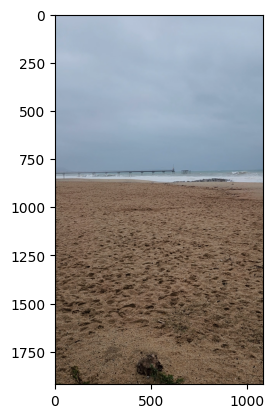

In [4]:
# Display one frame and check the frame information (for double-check)
ret, frame = video.read()
print("Image size (H, W, C) is:", frame.shape)
plt.imshow(frame[..., ::-1])

## Create new version of the input video

In [5]:
# create the VideoWriter objects. 
# output_border: since I want to create a grayscale video added the False keyword, 
# otherwise the VideoWriter object is a BGR by default (frame_width, frame_height, 3).
output_border = cv2.VideoWriter(output_folder+"sea_border.mp4", cv2.VideoWriter_fourcc(*"mp4v"), 10, 
                                (frame_width, frame_height), False)
# output_corners: BGR object
output_corners = cv2.VideoWriter(output_folder+"sea_corners.mp4", 
                                 cv2.VideoWriter_fourcc(*"mp4v"), 10, (frame_width, frame_height), True)

In [6]:
# setup of the feature params for the corner identification
feature_params = dict(maxCorners=500,qualityLevel=0.2,
                      minDistance=15,blockSize=9)

In [7]:
# create the new videos
while video.isOpened():
    # Capture frame-by-frame
    ret, frame = video.read()
    
    if ret:
        # Write the frame to the output files
        frame_border = cv2.Canny(frame, 200, 255)
        output_border.write(frame_border)

        new_frame = frame.copy()
        frame_gray = cv2.cvtColor(new_frame, cv2.COLOR_BGR2GRAY)
        corners = cv2.goodFeaturesToTrack(frame_gray, **feature_params)
        if corners is not None:	
            for x, y in np.float32(corners).reshape(-1, 2):
                x,y = int(x),int(y)
                cv2.circle(new_frame, (x,y), 10, (0, 0, 255),2)
        output_corners.write(new_frame)

    # Break the loop
    else:
        break

video.release()
output_border.release()
output_corners.release()